# ③ EDA — 탐색적 데이터 분석
**11team · 서울 지하철 혼잡도 분석**

2021년 6월 기준으로 ① 시간대 패턴 ② 호선별 ③ 역별 혼잡 ④ 방향성(베드타운 vs 업무지구)을 탐색한다.


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
NAVY, RED, BLUE = '#1D3557', '#E63946', '#457B9D'

SUBWAY_DIR = r"C:/Users/최용우/Downloads/drive-download-20260625T013956Z-3-001/dataset"
def read_csv_auto(p, **k):
    for e in ['utf-8-sig','cp949','euc-kr','utf-8']:
        try: return pd.read_csv(p, encoding=e, **k)
        except UnicodeDecodeError: continue

metro = read_csv_auto(f"{SUBWAY_DIR}/Seoul_subway_data_20210705.csv")
on_cols  = [c for c in metro.columns if '승차인원' in c]
off_cols = [c for c in metro.columns if '하차인원' in c]
slots    = [c.replace(' 승차인원','') for c in on_cols]
jun = metro[metro['사용월']==202106].copy()
print("2021.06 :", jun.shape, "/ 역", jun['지하철역'].nunique(), "개")

2021.06 : (608, 52) / 역 520 개


## 1. 시간대별 승·하차 패턴 — 출근/퇴근 피크

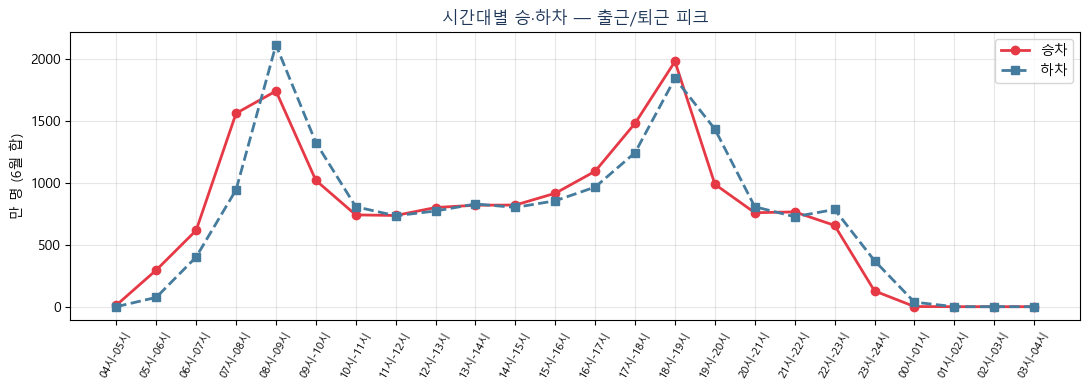

승차 피크: 18시-19시 | 하차 피크: 08시-09시


In [2]:
on_sum = jun[on_cols].sum().values; off_sum = jun[off_cols].sum().values
fig, ax = plt.subplots(figsize=(11,4))
x = range(len(slots))
ax.plot(x, on_sum/1e4,  'o-',  color=RED,  lw=2, label='승차')
ax.plot(x, off_sum/1e4, 's--', color=BLUE, lw=2, label='하차')
ax.set_xticks(list(x)); ax.set_xticklabels(slots, rotation=60, fontsize=8)
ax.set_ylabel('만 명 (6월 합)'); ax.set_title('시간대별 승·하차 — 출근/퇴근 피크', color=NAVY)
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()
print("승차 피크:", slots[int(np.argmax(on_sum))], "| 하차 피크:", slots[int(np.argmax(off_sum))])

## 2. 호선별 총 이용

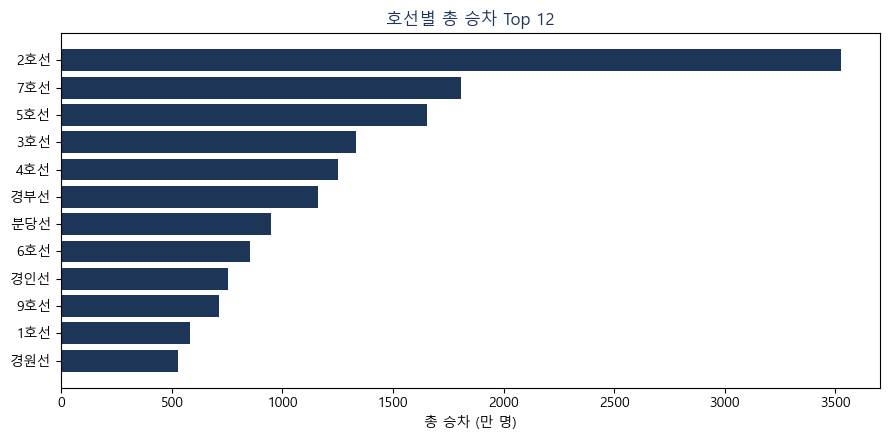

In [3]:
jun['총승차'] = jun[on_cols].sum(axis=1); jun['총하차'] = jun[off_cols].sum(axis=1)
line = jun.groupby('호선명')['총승차'].sum().sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(9,4.5))
ax.barh(line.index[::-1], line.values[::-1]/1e4, color=NAVY)
ax.set_xlabel('총 승차 (만 명)'); ax.set_title('호선별 총 승차 Top 12', color=NAVY)
plt.tight_layout(); plt.show()

## 3. 역별 혼잡 — 승차 최다역 Top 10

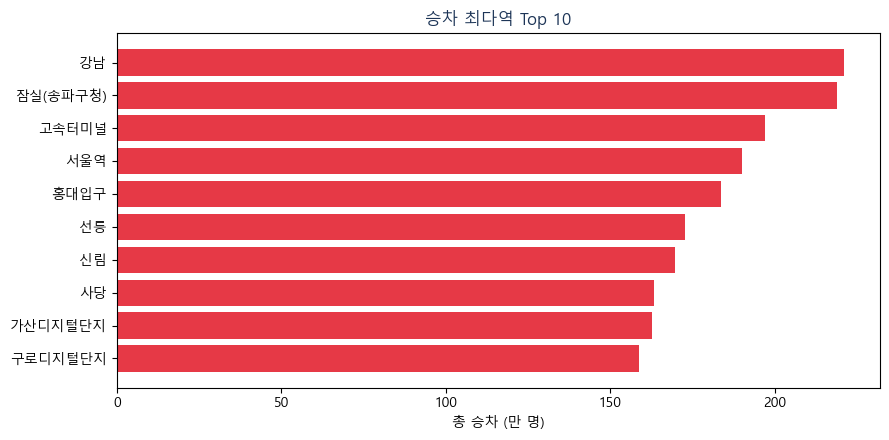

In [4]:
st_on = jun.groupby('지하철역')['총승차'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(9,4.5))
ax.barh(st_on.index[::-1], st_on.values[::-1]/1e4, color=RED)
ax.set_xlabel('총 승차 (만 명)'); ax.set_title('승차 최다역 Top 10', color=NAVY)
plt.tight_layout(); plt.show()

## 4. 방향성 — 베드타운 vs 업무지구
아침(07–09시) **승차비율** = 아침승차 / (아침승차 + 아침하차).
- 높으면 → 아침에 **타는** 역 = 주거지(베드타운)
- 낮으면 → 아침에 **내리는** 역 = 업무지구

In [5]:
am_on  = [c for c in on_cols  if c.startswith(('07시','08시'))]
am_off = [c for c in off_cols if c.startswith(('07시','08시'))]
jun['아침승차'] = jun[am_on].sum(axis=1); jun['아침하차'] = jun[am_off].sum(axis=1)
st = jun.groupby('지하철역').agg(아침승차=('아침승차','sum'), 아침하차=('아침하차','sum'))
st = st[(st['아침승차']+st['아침하차']) > 10000]          # 한산한 역 제외
st['아침승차비율'] = st['아침승차'] / (st['아침승차']+st['아침하차'])
print("=== 업무지구형 (아침 하차 우세) Top 5 ===")
print(st.nsmallest(5,'아침승차비율')['아침승차비율'].round(3).to_string())
print("\n=== 베드타운형 (아침 승차 우세) Top 5 ===")
print(st.nlargest(5,'아침승차비율')['아침승차비율'].round(3).to_string())

=== 업무지구형 (아침 하차 우세) Top 5 ===
지하철역
종각       0.042
시청       0.049
을지로입구    0.049
국회의사당    0.050
을지로3가    0.055

=== 베드타운형 (아침 승차 우세) Top 5 ===
지하철역
계양     0.908
까치산    0.895
장암     0.886
솔샘     0.882
강매     0.882


---
## ✅ EDA 요약
- **출근 하차피크 08–09시 / 퇴근 승차피크 18–19시** → 방향성 뚜렷
- **2호선** 최다, 강남·잠실·고속터미널 등 혼잡 허브
- **업무지구형**(강남·중구권) vs **베드타운형** 역이 명확히 갈림

### ▶ 다음 단계 (④ 심화)
- 역 → 자치구 → **주간인구지수 Join**으로 방향성 실증
- **역×시간 핫스팟 히트맵**
- **folium 혼잡 지도**